# Predicting a Continuous Target with Regression

- Author: Jaya Srinivas
- Date: 2026-07
- Custom Project (Phase 5)


## Overview

This custom project uses the **mpg** dataset (Seaborn's built-in `mpg`,
fuel economy for 1970s-1980s cars).

We predict `mpg` (miles per gallon) from a car's mechanical specs.
This target is **numeric**, so this is a:

- supervised ML problem (we've chosen a target)
- a regression problem (the target is numeric)

Compared to the example project (penguins, one feature, plain `LinearRegression`), here we:

- use **multiple numeric features** at once
- compare a plain `LinearRegression` baseline against a regularized `ElasticNet` model
- add `PolynomialFeatures` (degree 2) to see whether curvature helps
- report MAE, RMSE, and R-squared for every model, not just one

## Section 1. Project Setup and Imports

In [ ]:
# Section 1

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## Section 2. Load and Prepare the Data

In [ ]:
# Section 2 - load data

# mpg: fuel economy and specs for 1970s-1980s cars.
DATASET_NAME = "mpg"

df = sns.load_dataset(DATASET_NAME)
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded: 398 rows, 9 columns


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
# CUSTOM: ANALYST CHOICE - multiple numeric features (X) and one numeric target (y).
TARGET_COL = "mpg"
FEATURE_COLS = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
]

TARGET_LABEL = "Fuel economy (mpg)"

df_model = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
print(f"Original rows: {df.shape[0]}  Model rows: {df_model.shape[0]}")

X = df_model[FEATURE_COLS].to_numpy()
y = df_model[TARGET_COL].to_numpy()

Original rows: 398  Model rows: 392


## Section 3. Split into Train and Test



In [4]:
# === Section 3. Split into Train and Test ===

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Train rows: 313
Test rows: 79


## Section 4. Fit and Compare Models

In [ ]:
# === Section 4. Fit and Compare Models ===


def evaluate(name, y_true, y_pred):
    # Compute MAE, RMSE, R-squared and print them.
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:>24s}  MAE={mae:6.3f}  RMSE={rmse:6.3f}  R2={r2:6.3f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}


results = []

# Model 1: Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
results.append(evaluate("Linear Regression", y_test, y_pred_lin))

       Linear Regression  MAE= 2.504  RMSE= 3.241  R2= 0.794


In [ ]:
# Model 2: ElasticNet
en_model = ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=RANDOM_STATE)
en_model.fit(X_train, y_train)
y_pred_en = en_model.predict(X_test)
results.append(evaluate("ElasticNet", y_test, y_pred_en))

              ElasticNet  MAE= 2.515  RMSE= 3.260  R2= 0.792


In [ ]:
# Model 3: Polynomial features (
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_en_model = ElasticNet(
    alpha=0.5, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10000
)
poly_en_model.fit(X_train_poly, y_train)
y_pred_poly_en = poly_en_model.predict(X_test_poly)
results.append(evaluate("Polynomial (deg 2) + ElasticNet", y_test, y_pred_poly_en))

Polynomial (deg 2) + ElasticNet  MAE= 2.014  RMSE= 2.737  R2= 0.853


/Users/jaya/Repos/ml-04-regression/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.204175e+03, tolerance: 1.975e+00
  model = cd_fast.enet_coordinate_descent(


## Section 5. Compare Results

In [8]:
# === Section 5. Compare Results ===

results_df = pd.DataFrame(results).set_index("model")
results_df

,MAE,RMSE,R2
model,,,
Linear Regression,2.503860,3.240736,0.794235
ElasticNet,2.515137,3.259848,0.791801
Polynomial (deg 2) + ElasticNet,2.014247,2.737077,0.853223


### Interpretation

Fill in after running:

- Which model has the lowest test RMSE?
- Does ElasticNet's regularization help or hurt versus plain Linear Regression here?
- Does adding polynomial features improve test error, or only train error (a sign of overfitting)?

## Section 6. Visualize Actual vs. Predicted

Best model by test RMSE: Polynomial (deg 2) + ElasticNet


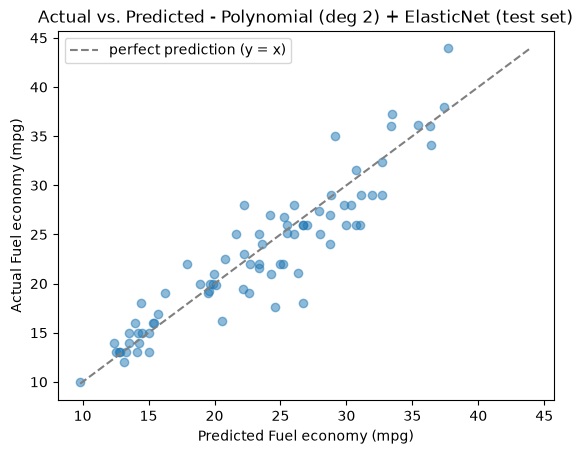

In [9]:
# === Section 6. Visualize Actual vs. Predicted (best model, test set) ===

predictions_map = {
    "Linear Regression": y_pred_lin,
    "ElasticNet": y_pred_en,
    "Polynomial (deg 2) + ElasticNet": y_pred_poly_en,
}
best_name = results_df["RMSE"].idxmin()
y_pred_best = predictions_map[best_name]
print(f"Best model by test RMSE: {best_name}")

plt.figure()
plt.scatter(y_pred_best, y_test, alpha=0.5)
lims = [min(y_pred_best.min(), y_test.min()), max(y_pred_best.max(), y_test.max())]
plt.plot(lims, lims, linestyle="--", color="gray", label="perfect prediction (y = x)")
plt.xlabel(f"Predicted {TARGET_LABEL}")
plt.ylabel(f"Actual {TARGET_LABEL}")
plt.title(f"Actual vs. Predicted - {best_name} (test set)")
plt.legend()
plt.show()

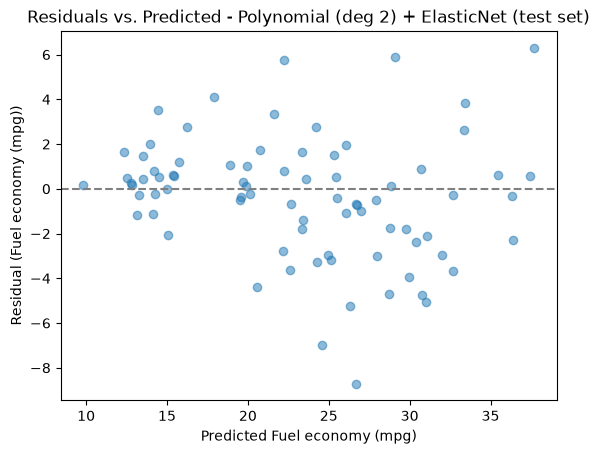

In [10]:
# Residual plot for the same best model: random scatter around 0
# means the fit has no obvious leftover pattern.
residuals = y_test - y_pred_best

plt.figure()
plt.scatter(y_pred_best, residuals, alpha=0.5)
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel(f"Predicted {TARGET_LABEL}")
plt.ylabel(f"Residual ({TARGET_LABEL})")
plt.title(f"Residuals vs. Predicted - {best_name} (test set)")
plt.show()

## Section 7. Summary and Next Steps

In [11]:
# === Section 7. Summary ===

print("========================")
print("SUMMARY")
print("========================")
print(f"Dataset:  {DATASET_NAME} (seaborn)")
print(f"Features: {FEATURE_COLS}")
print(f"Target:   {TARGET_COL}  (regression)")
print(results_df)
print(f"Best model (lowest test RMSE): {best_name}")
print("========================")

SUMMARY
Dataset:  mpg (seaborn)
Features: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
Target:   mpg  (regression)
                                      MAE      RMSE        R2
model                                                        
Linear Regression                2.503860  3.240736  0.794235
ElasticNet                       2.515137  3.259848  0.791801
Polynomial (deg 2) + ElasticNet  2.014247  2.737077  0.853223
Best model (lowest test RMSE): Polynomial (deg 2) + ElasticNet
